# OOF Evaluation — Diagnostics

This notebook inspects out-of-fold predictions exported by a completed modelling run and focuses on diagnostic plots that help verify whether the model fit is trustworthy.<br>
**Workflow summary:** load a manifest-driven OOF artifact set, validate the selected run metadata, visualize residual behavior on the original scale, then save the diagnostic figures.


## 1. Imports and Configuration
**Purpose:** Load the plotting/statistics libraries and manifest-aware helper functions needed for OOF diagnostics.<br>
**Inputs:** local `src/` package path, run identifiers, and plotting dependencies.<br>
**Outputs:** imported libraries and the notebook constants that identify the target run.<br>
**How to Verify:** the configuration cell should print the requested run id and optional target override without import errors.


In [1]:
# Ensure the notebook can import local helper modules even when it is launched
# from a nested working directory inside the repository.
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'data_modelling').exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError('Could not locate repo src/ directory for notebook imports.')


In [2]:
# Core libraries
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from data_modelling.run_context import (
    format_exported_model_label,
    get_exported_model_info,
    load_run_context,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'gam-linear-log'  # For GAM OOF evaluation use: 'gam-linear-log', 'gam-linear', or 'gam-gamma'.
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RESULTS_ROOT = Path('../../results/interpretable_model') / MODEL_ID / RUN_NAME
TABLES_DIR = RESULTS_ROOT / 'tables'
PLOTS_DIR = RESULTS_ROOT / 'plots'

print(f'Results root: {RESULTS_ROOT.resolve()}')
print(f'Model ID: {MODEL_ID}')
print(f'Run: {RUN_NAME}')
print(f'TARGET_COL override: {TARGET_COL}')


Results root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Model ID: gam-linear-log
Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
TARGET_COL override: None


## 2. Load Run Manifest and Nested-Resampling Artifacts
**Purpose:** Reconstruct one completed modelling run from its manifest and load the OOF tables needed for diagnostics.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, optional `TARGET_COL`, and the manifest-linked nested-resampling outputs.<br>
**Outputs:** resolved run metadata, loaded OOF dataframe, loaded OOF metrics table, and target/prediction arrays on the original scale.<br>
**How to Verify:** confirm the printed manifest path, model-data path, metrics path, loaded run label, and target/feature counts before plotting residuals.


In [3]:
# OOF diagnostics require a variant-level manifest plus the exported model-data-with-OOF
# table. The helper loads optional OOF metrics when they were written during training.
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest_path = run_ctx.manifest_path
manifest = run_ctx.manifest

# The top-level `gam` manifest points at the selected final model, not a single variant's
# OOF table, so this notebook requires a GAM variant id instead.
if MODEL_ID == 'gam':
    raise ValueError("Use a GAM variant MODEL_ID for OOF evaluation: 'gam-linear-log', 'gam-linear', or 'gam-gamma'.")

run_info = get_exported_model_info(manifest)
run_label = format_exported_model_label(run_info)
selection_metric_value = run_info['selection_metric_value']
selection_metric_value_display = (
    f'{selection_metric_value:.6f}'
    if isinstance(selection_metric_value, (int, float)) and not isinstance(selection_metric_value, bool)
    else str(selection_metric_value)
)

target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
TABLES_DIR = run_ctx.tables_dir
PLOTS_DIR = run_ctx.plots_dir
POOR_WELL_QUANTILE = manifest['analysis'].get('poor_well_quantile', 0.20)

nested_resampling = run_ctx.nested_resampling
model_data_path = run_ctx.model_data_path
metrics_path = run_ctx.metrics_path

model_df_oof = run_ctx.model_df_oof
oof_metrics_df = run_ctx.oof_metrics_df

X = model_df_oof[feature_cols]
y_oof_orig = model_df_oof['target_orig'].to_numpy()
y_oof_pred_orig = model_df_oof['oof_pred_orig'].to_numpy()

print(f'Loaded manifest: {manifest_path}')
print(f'Loaded model data: {model_data_path}')
print(f'Loaded OOF metrics: {metrics_path}')
print(f'Target: {target_col} | Features: {len(feature_cols)}')
print(f'Loaded run: {run_label}')
print(
    'Selection metric: '
    f"{run_info['selection_metric_name']}={selection_metric_value_display}"
)
if oof_metrics_df is not None:
    display(oof_metrics_df)


Loaded manifest: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
Loaded model data: ../../results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/model_data_with_oof_ml_ade_log.csv
Loaded OOF metrics: ../../results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv
Target: ml_ade_log | Features: 13
Loaded run: LinearGAM (log) (linear, target_mode=log)
Selection metric: mean_outer_rmse=0.396787


,Split,R²,MAE,RMSE
0,OOF,0.533898,0.289409,0.397279


## 3. Model-Fit Diagnostics (OOF)
**Purpose:** Visualize prediction agreement, residual structure, and normality assumptions using OOF predictions only.<br>
**Inputs:** `target_orig`, `oof_pred_orig`, and the loaded model metadata.<br>
**Outputs:** residual arrays and a saved diagnostics plot summarizing model fit.<br>
**How to Verify:** the scatter should align around the diagonal for well-fit runs, the residual histogram should be centered near zero, and the QQ plot should not show severe tail pathologies without explanation.


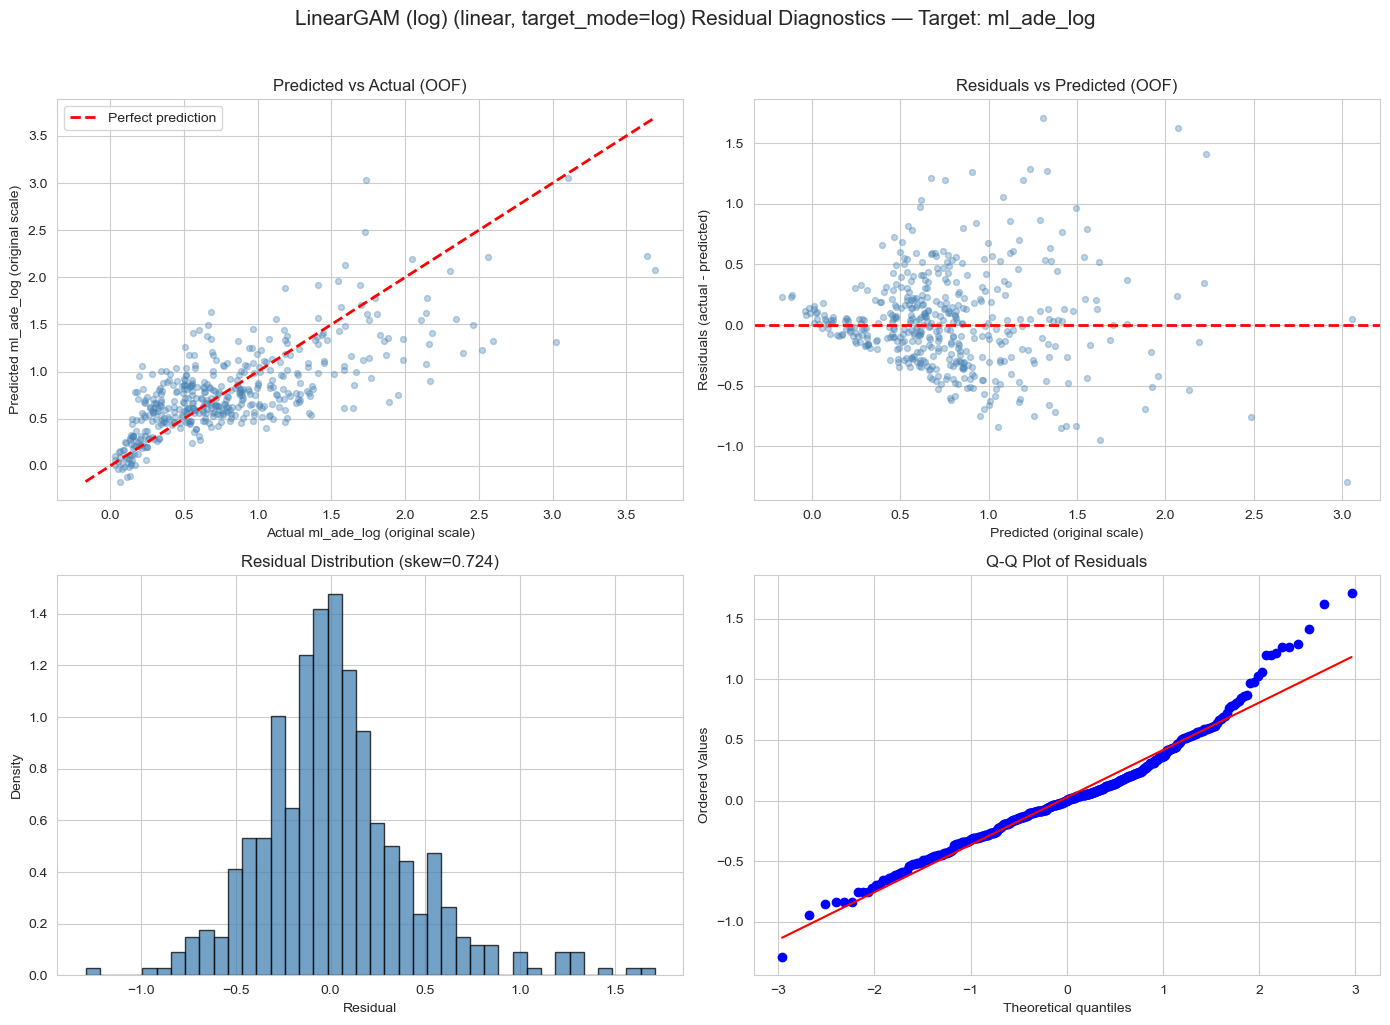

Diagnostics plot saved to: ../../results/interpretable_model/gam-linear-log/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/residual_diagnostics_oof_ml_ade_log.png
Residual mean:   0.025922
Residual median: -0.000399
Residual std:    0.396432


In [5]:
# All diagnostics operate on the original target scale so any bias or spread can be read
# directly in the same units as the raw ADE/FDE-style target.
residuals_oof = y_oof_orig - y_oof_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_oof_orig, y_oof_pred_orig, alpha=0.35, s=18, color='steelblue')
lims = [
    min(np.min(y_oof_orig), np.min(y_oof_pred_orig)),
    max(np.max(y_oof_orig), np.max(y_oof_pred_orig)),
]
axes[0, 0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0, 0].set_xlabel(f'Actual {target_col} (original scale)')
axes[0, 0].set_ylabel(f'Predicted {target_col} (original scale)')
axes[0, 0].set_title('Predicted vs Actual (OOF)')
axes[0, 0].legend()

axes[0, 1].scatter(y_oof_pred_orig, residuals_oof, alpha=0.35, s=18, color='steelblue')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted (original scale)')
axes[0, 1].set_ylabel('Residuals (actual - predicted)')
axes[0, 1].set_title('Residuals vs Predicted (OOF)')

axes[1, 0].hist(residuals_oof, bins=40, density=True, alpha=0.75, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title(f'Residual Distribution (skew={stats.skew(residuals_oof):.3f})')

stats.probplot(residuals_oof, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.suptitle(f'{run_label} Residual Diagnostics — Target: {target_col}', fontsize=15, y=1.02)
plt.tight_layout()
diag_path = PLOTS_DIR / f'residual_diagnostics_oof_{target_col}.png'
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Diagnostics plot saved to: {diag_path}')
print(f'Residual mean:   {residuals_oof.mean():.6f}')
print(f'Residual median: {np.median(residuals_oof):.6f}')
print(f'Residual std:    {residuals_oof.std():.6f}')


## 4. Saved Artifacts
**Purpose:** Record the key diagnostic artifacts and metadata associated with this OOF analysis run.<br>
**Inputs:** manifest path, metrics path, saved diagnostic plot path, and resolved run label.<br>
**Outputs:** a concise audit trail printed at the end of the notebook.<br>
**How to Verify:** confirm the printed files exist and that the run label matches the variant selected at the top of the notebook.


In [ ]:
print("Saved artifacts:")
print(f"- Run manifest:      {manifest_path}")
print(f"- OOF metrics table: {metrics_path}")
print(f"- Diagnostics plot:  {diag_path}")
print(
    f"- Loaded run:        {run_info['name']} "
    f"({run_info['kind']}, target_mode={run_info['target_mode']})"
)
print(f"- Plot directory:    {PLOTS_DIR}")


Saved artifacts:
- Run manifest:      /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
- OOF metrics table: ../../results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/metrics_oof_ml_ade_log.csv
- Diagnostics plot:  ../../results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/residual_diagnostics_oof_ml_ade_log.png
- Plot directory:    ../../results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots
